In [1]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import numpy as np
import utils
import plotting
import pprint
import matplotlib.pyplot as plt
from solvers import SmdpForwardSearchSolver, SmdpMctsSolver, DiscreteTimeIpSolver, RuleBasedSolver
from problem import State, Action, Request, ServiceWindow, PntSchedulingProblem

pp = pprint.PrettyPrinter()
# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

# Toy Problem

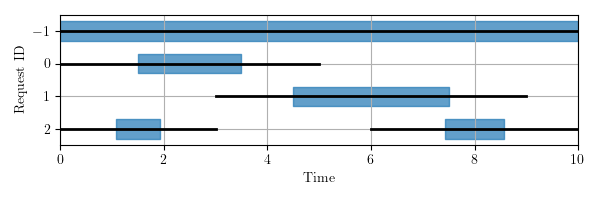

In [11]:
requests = [
    Request(id=-1, user_id=-1, rv=None, start=0, end=10, duration=10),  # Dummy request
    Request(id=0, user_id=1, rv=None, start=0, end=10, duration=2),
    Request(id=1, user_id=2, rv=None, start=0, end=10, duration=3),
    Request(id=2, user_id=3, rv=None, start=0, end=10, duration=2),
]

service_windows = [
    ServiceWindow(
        id=-1, request_id=-1, start=0, end=10, reward=0, power_gen=0, data_gen=0
    ),  # Dummy service window
    ServiceWindow(
        id=0, request_id=0, start=0, end=5, reward=1, power_gen=-1, data_gen=1
    ),
    ServiceWindow(
        id=1, request_id=1, start=3, end=9, reward=2, power_gen=-1, data_gen=1
    ),
    ServiceWindow(
        id=2, request_id=2, start=0, end=3, reward=3, power_gen=-1, data_gen=1
    ),
    ServiceWindow(
        id=2, request_id=2, start=6, end=10, reward=5, power_gen=-1, data_gen=1
    ),
]

transition_times = np.ones((len(service_windows), len(service_windows)))
transition_times[np.diag_indices(len(service_windows))] = 0
energy_gen_func = lambda ts, te: 0.25 * (te - ts)
data_gen_func = lambda ts, te: -0.25 * (te - ts)


problem = PntSchedulingProblem(
    requests=requests,
    service_windows=service_windows,
    transition_times=transition_times,
    N_max_actions=50,
    min_action_duration=1,
    max_energy=10,
    min_energy=2,
    max_data=10,
    min_data=2,
    energy_gen_func=energy_gen_func,
    data_gen_func=data_gen_func,
)

fig, ax = plt.subplots(1, 1, figsize=(6, 2))
plotting.plot_requests_service_windows(requests, service_windows, ax=ax)

Solving Forward Search (progress in hours): 100%|██████████| 10/10 [00:00<00:00, 4759.22it/s]


Total reward: 7.33


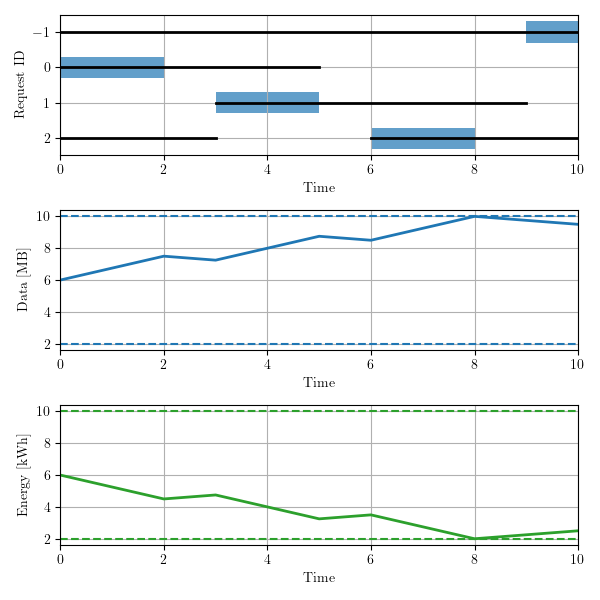

In [15]:
# Forward search
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=100, gamma=0.9)
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy):.2f}")
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

Solving Forward Search (progress in hours): 100%|██████████| 10/10 [00:01<00:00,  7.25it/s]


Total reward: 7.50


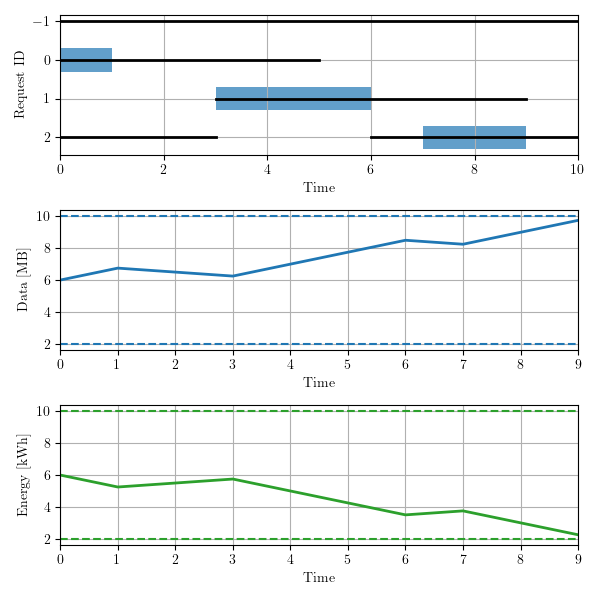

In [16]:
# MCTS
s = problem.initial_state()
solver = SmdpMctsSolver(problem)
policy = solver.solve(s, d=10, gamma=0.9, n=int(5e3), c=10)
print(f"Total reward: {problem.total_reward(policy):.2f}")
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) Mar 17 04:40:57 PM: Your problem has 40 variables, 131 constraints, and 0 parameters.
(CVXPY) Mar 17 04:40:57 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 17 04:40:57 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 17 04:40:57 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 17 04:40:57 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Mar 17 04:40:57 PM: Compiling problem (target solver=GUROBI).


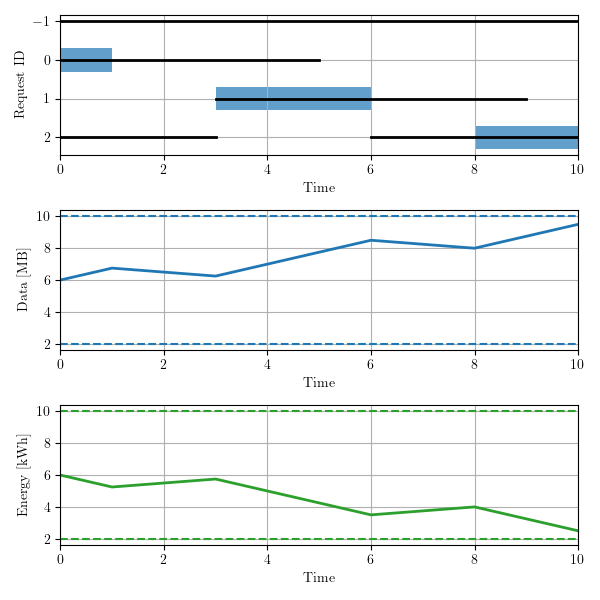

In [17]:
# IP
solver = DiscreteTimeIpSolver(problem)
policy = solver.solve(s, time_step=1)
print(f"Total reward: {problem.total_reward(policy):.2f}")
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

# Experiment 1

## Users

In [45]:
import pathfinder_data

orbital_elements = pathfinder_data.orbital_elements.copy()
users = pathfinder_data.users.copy()

# Epoch (TAI)
epoch_0 = pnt.SpiceInterface.string_to_tai("2026/1/01 00:00:00.000 UTC")

# Classical orbital elements (a, e, i, W, w, M) [km, -, rad, rad, rad, rad]
coe_OP = orbital_elements
coe_OP[2:] = np.deg2rad(coe_OP[2:])
rv0_moon_sat_OP = pnt.classical_to_cartesian(coe_OP, pnt.MU_MOON)
rv0_moon_sat_mi = pnt.CoordConverter.convert(epoch_0, rv0_moon_sat_OP, pnt.OP, pnt.MI)

# Time
sma = coe_OP[0]  # [km] Semi-major axis
period = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)  # [s] Orbital period
Dt = 5 * pnt.SECS_PER_MINUTE  # [s] Simulation time step
dt = 5 * pnt.SECS_PER_MINUTE  # [s] Propagation time step
tf = 1 * pnt.SECS_PER_DAY  # [s] Simulation final time
N_t = int(tf / Dt)  # [-] Number of time steps
tspan = np.linspace(0, tf, N_t)  # [s] Time since first epoch
epochs = epoch_0 + tspan  # [s] Epochs (TAI)

# Dynamics (three-body)
dynamics = pnt.NBodyDynamics()
dynamics.set_primary_body(pnt.Body.Moon())
dynamics.add_body(pnt.Body.Earth())
dynamics.set_time_step(dt)

# Propagation
# rv_{from}_{to}_{frame} [km, km/s] (x, y, z, vx, vy, vz)
rv_moon_sat_mi = dynamics.propagate(rv0_moon_sat_mi, epoch_0, epochs)
rv_moon_sat_pa = pnt.CoordConverter.convert(epochs, rv_moon_sat_mi, pnt.MI, pnt.PA)
rv_moon_earth_mi = pnt.SpiceInterface.get_body_pos_vel(epochs, pnt.MOON, pnt.EARTH)
rv_moon_earth_pa = pnt.CoordConverter.convert(epochs, rv_moon_earth_mi, pnt.MI, pnt.PA)
rv_moon_sun_mi = pnt.SpiceInterface.get_body_pos_vel(epochs, pnt.MOON, pnt.SUN)
rv_moon_sun_pa = pnt.CoordConverter.convert(epochs, rv_moon_sun_mi, pnt.MI, pnt.PA)

# Attitude
r_sun = rv_moon_sun_mi[:, 0:3] - rv_moon_sat_mi[:, 0:3]
r_earth = rv_moon_earth_mi[:, 0:3] - rv_moon_sat_mi[:, 0:3]

e_sun = r_sun / np.linalg.norm(r_sun, axis=1)[:, None]
e_earth = r_earth / np.linalg.norm(r_earth, axis=1)[:, None]

r = rv_moon_sat_mi[:, 0:3]
v = rv_moon_sat_mi[:, 3:6]
r_norm = r / np.linalg.norm(r, axis=1)[:, None]
v_norm = v / np.linalg.norm(v, axis=1)[:, None]
e_nadir = -r_norm


def cross_norm(a, b):
    return np.cross(a, b) / np.linalg.norm(np.cross(a, b), axis=1)[:, None]


# Yaw-Steering (YS)
ez_ys = -r_norm
ey_ys = cross_norm(e_nadir, e_sun)
ex_ys = cross_norm(ey_ys, ez_ys)

In [19]:
def propagate_orbital_user(user: dict) -> np.array:
    """
    Propagate a user on orbit around the Moon.
    :param coe: [a, e, i, W, w, M] [km, -, deg, deg, deg, deg]
    :param frame: Frame
    :return: [x, y, z, vx, vy, vz] [km, km/s]
    """
    coe = user["orbital_elements"].copy()
    frame = user["frame"]
    coe[2:] = np.deg2rad(coe[2:])
    rv0 = pnt.classical_to_cartesian(coe, pnt.MU_MOON)
    rv0_mi = pnt.CoordConverter.convert(epoch_0, rv0, frame, pnt.MI)
    rv_mi = dynamics.propagate(rv0_mi, epoch_0, epochs)
    return rv_mi


def propagate_surface_user(user: dict) -> np.array:
    """
    Propagate a user on the surface of the Moon.
    :param lat_lon_alt: [lat, lon, alt] [deg, deg, km]
    :return: [x, y, z, vx, vy, vz] [km, km/s]
    """
    lat_lon_alt = user["location"].copy()
    lat_lon_alt[:2] = np.deg2rad(lat_lon_alt[:2])
    rv_pa = np.zeros((N_t, 6))
    rv_pa[:, :3] = pnt.geographical_to_cartesian(lat_lon_alt, pnt.R_MOON)
    return rv_pa


# Users
N_users = len(users)
user_type = np.array([user["type"] for user in users])
rv_moon_user_mi = np.zeros((N_users, N_t, 6))
rv_moon_user_pa = np.zeros((N_users, N_t, 6))
az_el_rho = np.zeros((N_users, N_t, 3))
for i, user in enumerate(users):
    if user["type"] == "orbital":
        rv_moon_user_mi[i] = propagate_orbital_user(user)
        rv_moon_user_pa[i] = pnt.CoordConverter.convert(
            epochs, rv_moon_user_mi[i], pnt.MI, pnt.PA
        )
    elif user["type"] == "surface":
        rv_moon_user_pa[i] = propagate_surface_user(user)
        rv_moon_user_mi[i] = pnt.CoordConverter.convert(
            epochs, rv_moon_user_pa[i], pnt.PA, pnt.MI
        )
    else:
        raise ValueError("Invalid user type")

    az_el_rho[i] = pnt.cartesian_to_azimuth_elevation_range(
        rv_moon_user_mi[i, :, :3], rv_moon_sat_mi[:, :3]
    )

surface_elev_mask = np.deg2rad(15)  # [rad] Elevation mask
orbital_elev_mask = np.deg2rad(2)  # [rad] Elevation mask
max_elevation = np.max(az_el_rho[:, :, 1], axis=1)
min_elevation = np.maximum(surface_elev_mask, max_elevation - np.deg2rad(90))
min_elevation[user_type == "orbital"] = orbital_elev_mask
print("Max elevation (geometry)   ", np.rad2deg(max_elevation).round(0))
print("Min elevation (requirement)", np.rad2deg(min_elevation).round(0))
user_visible = np.greater_equal(az_el_rho[:, :, 1], min_elevation[:, None])

Max elevation (geometry)    [79. 55. 42. 64. 79. 18.]
Min elevation (requirement) [ 2. 15. 15. 15.  2. 15.]


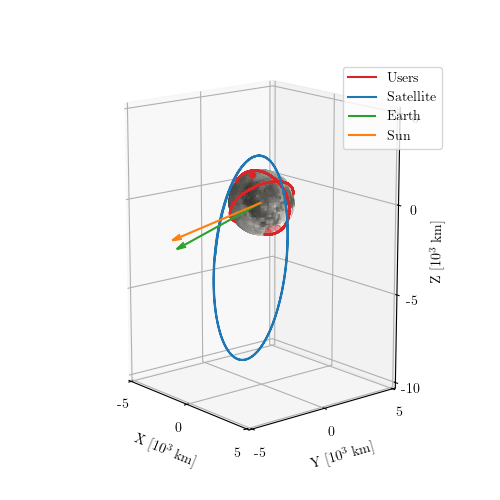

In [55]:
plotting.plot_satellites_users(
    rv_moon_sat_mi, rv_moon_user_mi, rv_moon_earth_mi, rv_moon_sun_mi, user_type
)

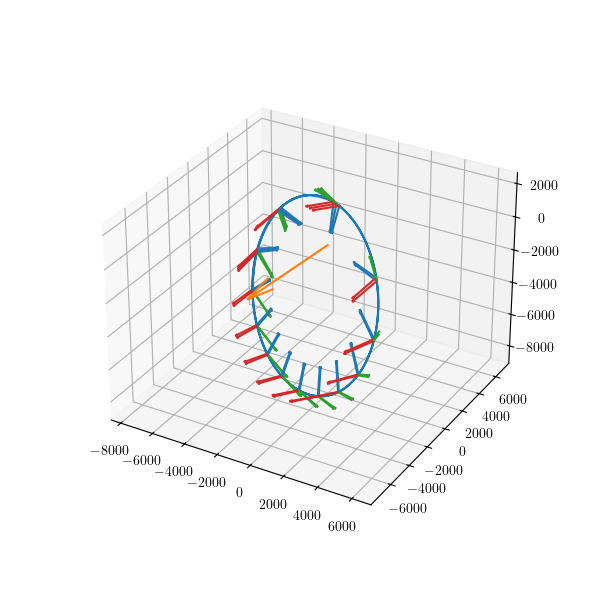

In [118]:
# Attitude
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

scale = 3 * pnt.R_MOON
plt.plot(rv_moon_sat_mi[:, 0], rv_moon_sat_mi[:, 1], rv_moon_sat_mi[:, 2])
e_moon_sun = rv_moon_sun_mi[0, 0:3] / np.linalg.norm(rv_moon_sun_mi[0, 0:3])
plt.quiver(
    0,
    0,
    0,
    e_moon_sun[0] * scale,
    e_moon_sun[1] * scale,
    e_moon_sun[2] * scale,
    color="tab:orange",
)
# Yaw-Steering Frame
scale = pnt.R_MOON
for i in range(0, N_t, 10):
    r_ys = rv_moon_sat_mi[i, 0:3]
    plt.quiver(
        *r_ys, *ex_ys[i] * scale, color="tab:red", label="X_ys", arrow_length_ratio=0.1
    )
    plt.quiver(
        *r_ys,
        *ey_ys[i] * scale,
        color="tab:green",
        label="Y_ys",
        arrow_length_ratio=0.1
    )
    plt.quiver(
        *r_ys, *ez_ys[i] * scale, color="tab:blue", label="Z_ys", arrow_length_ratio=0.1
    )

plt.axis("equal")
plt.show()

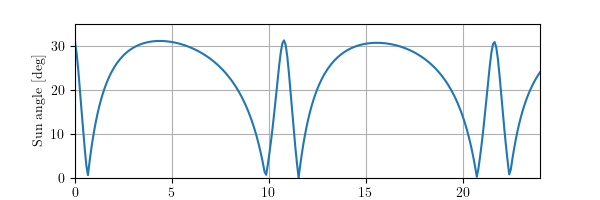

In [119]:
# Sun pointing
sun_angle_cos = np.sum(e_sun * ex_ys, axis=1)
sun_angle = np.arccos(sun_angle_cos)
fig, ax = plt.subplots(1, 1, figsize=(6, 2))
x = tspan / pnt.SECS_PER_HOUR
y = np.rad2deg(sun_angle)
plt.plot(x, y)
plt.xlabel("Time [h]")
plt.ylabel("Sun angle [deg]")
plt.xlim([0, 24])
plt.ylim([0, 35])
plt.grid()
plt.show()

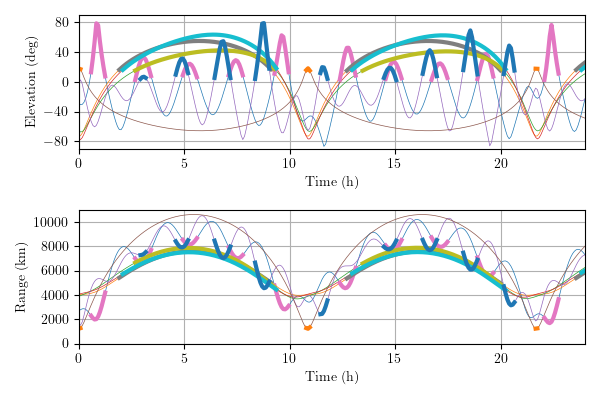

In [44]:
fig, axs = plt.subplots(2, 1, figsize=(6, 4))
plotting.plot_elevation_range(tspan, az_el_rho, user_visible, axs=axs)
axs[0].set_ylim([-90, 90])
axs[0].set_yticks(np.arange(-80, 80 + 1, 40))
axs[1].set_ylim([0, 11e3])
axs[1].set_yticks(np.arange(0, 12e3, 2e3))
plt.show()

In [120]:
# Contact durations
contact_durations = list[np.array]()
contact_start_ends = list[np.array]()
for i, user in enumerate(users):
    starts, ends = utils.get_start_end_indexes(user_visible[i])
    contact_start_ends.append(np.vstack((starts, ends)).T)
    contact_durations.append((ends - starts) * Dt / pnt.SECS_PER_MINUTE)
total_contact_durations = np.array([x.sum() for x in contact_durations])
contact_durations_pathfinder = np.array([user["contact"] for user in users])

print("Contact durations [min]")
pp.pprint(contact_durations)
print("Total contact durations [min]")
pp.pprint(total_contact_durations)
print("Pathfinder contact durations [min]")
pp.pprint(contact_durations_pathfinder)

Contact durations [min]
[array([45., 50., 45., 45., 45., 50., 50., 50., 50., 45.]),
 array([435., 440.,  30.]),
 array([400., 400.]),
 array([440., 440.,  15.]),
 array([ 5., 20., 40., 50., 45., 25., 40., 45., 45., 35.]),
 array([10., 15., 10.])]
Total contact durations [min]
array([475., 905., 800., 895., 350.,  35.])
Pathfinder contact durations [min]
array([150, 467, 529, 248, 100,  23])


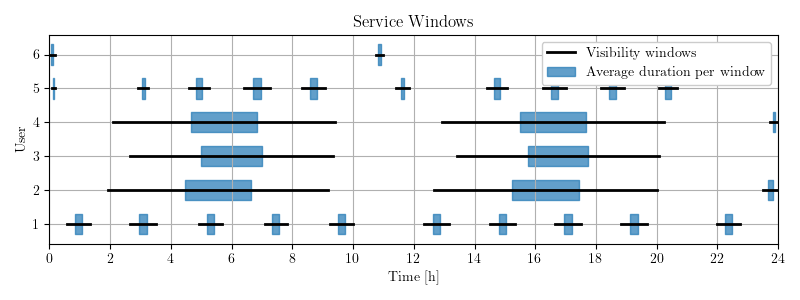

In [71]:
import matplotlib.pyplot as plt

duration_factor = 0.3
time_multiplier = Dt / pnt.SECS_PER_HOUR
plotting.plot_service_windows(contact_start_ends, duration_factor, time_multiplier)
plt.xlim(0, tf / pnt.SECS_PER_HOUR)
plt.xticks(np.arange(0, tf / pnt.SECS_PER_HOUR + 1, 2))
plt.tight_layout()
plt.show()

In [123]:
user_visible.shape

(6, 288)

In [155]:
# Navigation signal
fs = 2492.028e6  # Carrier frequency [Hz]
fc = 5.115e6  # Spread code frequency [Hz]
Tc = 1 / fc  # Spread code period [s]

# Receiver parameters
NF_lna = 1  # LNA noise figure [dB]
T_sys = 113  # System noise temperature [K]
B_dll = 0.5  # DLL bandwidth [Hz]
d = 1.0  # Early-late spacing [chips]
T_i = 0.02  # Coherent integration time [s]
B_fe = 2 * fc  # Front-end bandwidth [Hz]

# Constants
c = 2.998e8  # Speed of light [m/s]
k = -228.6  # Boltzmann constant [dBW/Hz/K]

# Link budget
rv_user_sat_mi = rv_moon_user_mi - rv_moon_sat_mi
r[~user_visible] = np.nan
# r = 8e6 # Distance [m]
EIRP = 30  # Equivalent isotropic radiated power [dBW]
L_fs = pnt.decimal2dB((4 * np.pi * r * fs / c) ** 2)  # Free space loss [dB]
L_fs = 10 * np.log10((4 * np.pi * r * fs / c) ** 2)  # Free space loss [dB]
Pr = EIRP - L_fs  # Received power [dBW]

# Antenna gain
T_atm = 290  # Atmospheric noise temperature [K]
T_eq = 10 * np.log10(
    T_sys + T_atm * (10 ** (NF_lna / 10) - 1)
)  # Equivalent noise temperature [dBK]

mu = 0.6  # Antenna efficiency
D_ant = 0.3  # Antenna diameter [m]
# Maximum antenna gain [dBi]
Gr_max = pnt.decimal2dB(mu * (np.pi * D_ant * fs / c) ** 2)
Gr_max = 6

theta = 0  # Beamwidth [deg]
theta_3dB = 40  # 3 dB beamwidth [deg]
Gr = pnt.decimal2dB(pnt.dB2decimal(Gr_max) - 12 * (theta / theta_3dB) ** 2)  # [dBi]

# Gain-to-noise temperature [dB]
GT = Gr - T_eq
# GT = -20
CN0 = Pr - k + GT  # Carrier-to-noise density ratio [dB-Hz]

# Error contributions
# Delay Lock Loop (DLL) error [m]
term_1 = (c * Tc) ** 2 * (B_dll * (1 - 0.5 * B_dll * T_i)) / (2 * CN0)
if d >= np.pi / (Tc * B_fe):
    sigma_p_dll_sq = term_1 * d
elif np.pi / (Tc * B_fe) > d > 1 / (Tc * B_fe):
    term_2 = (1 / (Tc * B_fe)) + ((Tc * B_fe) / (np.pi - 1)) * (
        d - (1 / (Tc * B_fe))
    ) ** 2
    term_3 = 1 + (2 / (T_i * CN0 * (2 - d)))
    sigma_p_dll_sq = term_1 * term_2 * term_3
else:  # d <= 1 / (T_c * B_fe)
    term_2 = 1 / (Tc * B_fe)
    term_3 = 1 + (1 / (T_i * CN0))
    sigma_p_dll_sq = term_1 * term_2 * term_3
sigma_p_dll = np.sqrt(sigma_p_dll_sq)

sigma_p_eph = 5  # Satellite ephemeris error [m]
sigma_p_rel = 0.31  # Residual relay delay error [m]
sigma_p_mul = 0.2  # Lunar multipath error [m]
sigma_p_non_eph = np.sqrt(sigma_p_dll**2 + sigma_p_rel**2 + sigma_p_mul**2)
sigma_p_tot = np.sqrt(4 * sigma_p_eph**2 + sigma_p_non_eph**2)

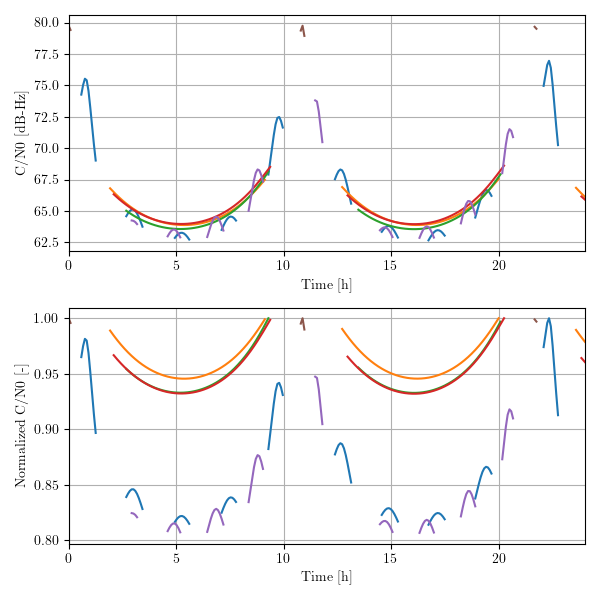

In [156]:
fig, ax = plt.subplots(2, 1, figsize=(6, 6))
x = tspan / pnt.SECS_PER_HOUR
plt.sca(ax[0])
plt.plot(x, CN0.T)
plt.xlabel("Time [h]")
plt.ylabel("C/N0 [dB-Hz]")
plt.xlim([x[0], x[-1]])
plt.grid()

plt.sca(ax[1])
CN0_norm = CN0.copy()
CN0_norm /= np.nanmax(CN0_norm, axis=1)[:, None]
plt.plot(x, CN0_norm.T)
plt.xlabel("Time [h]")
plt.ylabel("Normalized C/N0 [-]")
plt.xlim([x[0], x[-1]])
plt.grid()

plt.tight_layout()
plt.show()

In [163]:
# GDOP
user = 0
w = 10
s = 5
e = s + w
e_usr_sat = utils.normalize(rv_user_sat_mi[user, s:e, :3])
# G = np.hstack((e_usr_sat, np.ones((e_usr_sat.shape[0], 1))))
G = e_usr_sat
H = np.linalg.inv(G.T @ G)
gdop = np.sqrt(np.trace(H))
print(f"Duration {w * Dt / pnt.SECS_PER_HOUR:.2f} h")
print("PDOP", gdop)

Duration 0.83 h
PDOP 8.205954839195375


In [164]:
# Time in hours
duration_factor = 0.3

# Requests
requests = list[Request]()
requests.append(
    Request(
        id=-1,
        user_id=-1,
        rv=None,
        start=0,
        end=tf / pnt.SECS_PER_HOUR,
        duration=tf / pnt.SECS_PER_HOUR,
        priority=0,
    ),  # Dummy request
)
resquest_id = 0
for i, user in enumerate(users):
    requests.append(
        Request(
            id=resquest_id,
            user_id=user["id"],
            rv=rv_moon_user_mi[i],
            start=0,
            end=tf / pnt.SECS_PER_HOUR,
            duration=total_contact_durations[i]
            * pnt.SECS_PER_MINUTE
            / pnt.SECS_PER_HOUR
            * duration_factor,
        )
    )
    resquest_id += 1
N_requests = len(requests)

# Service windows
service_windows = list[ServiceWindow]()
window_id = 0
service_windows.append(
    ServiceWindow(
        id=-1,
        request_id=-1,
        start=0,
        end=tf / pnt.SECS_PER_HOUR,
    )  # Dummy service window
)
for i, request in enumerate(requests[1:]):
    for start, end in contact_start_ends[i]:
        service_windows.append(
            ServiceWindow(
                id=window_id,
                request_id=request.id,
                start=round(start * Dt / pnt.SECS_PER_HOUR, 1),
                end=round(end * Dt / pnt.SECS_PER_HOUR, 1),
            )
        )
        window_id += 1
N_service_windows = len(service_windows)

# Transition times
transition_times = np.ones((N_service_windows, N_service_windows))
transition_times *= 0.2  # hours
transition_times[np.diag_indices(N_service_windows)] = 0

# Energy and data generation functions
S_panels = 3 * 0.5 * 0.8  # [m^2] Solar panels area
I_earth = 1361  # [W/m^2] Solar irradiance
efficiency = 0.2  # Solar panels efficiency
P_max = round(S_panels * I_earth * efficiency)  # [W] Max power generation
P_max = 50  # [W] Max power generation
R_max = -2e3  # [kbps] Direct-To-Earth max data rate

payload_data_gen = 2.4  # [kbps] Payload data generation
payload_power_gen = 2 * P_max # [W] Payload power generation

def energy_gen_func(ts, te):

    if not isinstance(ts, np.ndarray):
        i_s = int(ts / Dt)
        i_e = int(te / Dt)
        if i_e > i_s:
            i_e += 1
        return P_max * np.sum(sun_angle_cos[i_s:i_e]) * Dt / pnt.SECS_PER_HOUR
    else:
        energy = np.zeros(len(ts))
        for i in range(len(ts)):
            i_s = int(ts[i] / Dt)
            i_e = int(te[i] / Dt)
            if i_e > i_s:
                i_e += 1
            energy[i] = P_max * np.sum(sun_angle_cos[i_s:i_e]) * Dt / pnt.SECS_PER_HOUR
        return energy


def data_gen_func(ts, te):
    return R_max * (te - ts)


# Problem
problem = PntSchedulingProblem(
    time_step=Dt,
    requests=requests,
    service_windows=service_windows,
    transition_times=transition_times,
    CN0=CN0,
    N_max_actions=100,
    min_action_duration=1,
    max_energy=10,
    min_energy=2,
    max_data=10,
    min_data=2,
    energy_gen_func=energy_gen_func,
    data_gen_func=data_gen_func,
)

TypeError: PntSchedulingProblem.__init__() got an unexpected keyword argument 'time_step'

In [114]:
# Forward search
np.random.seed(0)
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy_fs = solver.solve(s, d=3, gamma=0.7)

# Metrics
print(f"Total reward: {problem.total_reward(policy_fs):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy_fs)
pp.pprint(percentage)
print("Total:", round(np.mean(list(percentage.values())), 2))

Solving Forward Search (progress in hours): 100%|██████████| 24/24 [00:01<00:00, 17.31it/s]

Total reward: 2.48
Percentage of requests served:
{0: 46.32, 1: 22.1, 2: 0.0, 3: 0.0, 4: 80.0, 5: 100.0}
Total: 41.4


In [115]:
# MCTS
np.random.seed(0)
s = problem.initial_state()
solver = SmdpMctsSolver(problem)
policy_mcts = solver.solve(s, d=5, gamma=0.7, n=int(100), c=3)

# Metrics
print(f"Total reward: {problem.total_reward(policy_mcts):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy_mcts)
pp.pprint(percentage)
print("Total:", round(np.mean(list(percentage.values())), 2))

Solving Forward Search (progress in hours): 100%|██████████| 24/24 [00:00<00:00, 25.01it/s]

Total reward: 2.43
Percentage of requests served:
{0: 29.47, 1: 22.1, 2: 0.0, 3: 0.0, 4: 91.43, 5: 100.0}
Total: 40.5


In [116]:
# IP
np.random.seed(0)
solver = DiscreteTimeIpSolver(problem)
policy_ip = solver.solve(s, time_step=0.2)

# Metrics
print(f"Total reward: {problem.total_reward(policy_ip):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy_ip)
pp.pprint(percentage)
print("Total:", round(np.mean(list(percentage.values())), 2))

Service window 18 has duration 0. Try decreasing time step.
                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) Mar 17 05:37:18 PM: Your problem has 840 variables, 5241 constraints, and 0 parameters.
(CVXPY) Mar 17 05:37:19 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 17 05:37:19 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 17 05:37:19 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 17 05:37:19 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) 

In [108]:
# Rule-based
solver = RuleBasedSolver(problem)
policy_rb = solver.solve(s)

# Metrics
print(f"Total reward: {problem.total_reward(policy_rb):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy_rb)
pp.pprint(percentage)
print("Total:", round(np.mean(list(percentage.values())), 2))

Total reward: 3.99
Percentage of requests served:
{0: 100.0, 1: 99.45, 2: 0.0, 3: 0.0, 4: 100.0, 5: 100.0}
Total: 66.58


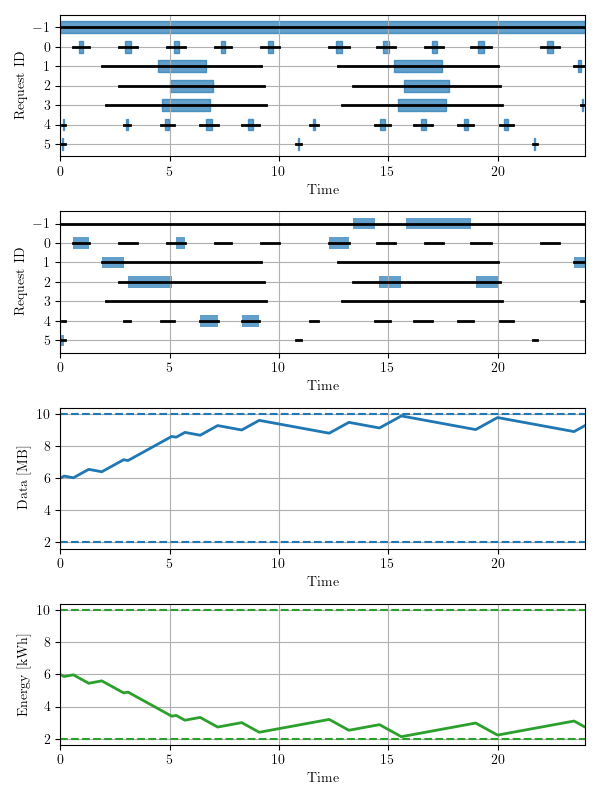

In [259]:
# Forward search
fig, axs = plt.subplots(4, 1, figsize=(6, 8))
plotting.plot_requests_service_windows(requests, service_windows, ax=axs[0])
plotting.plot_requests_service_windows(requests, service_windows, policy_fs, ax=axs[1])
plotting.plot_resources(problem, policy_fs, ax=axs[2:4])
plt.show()

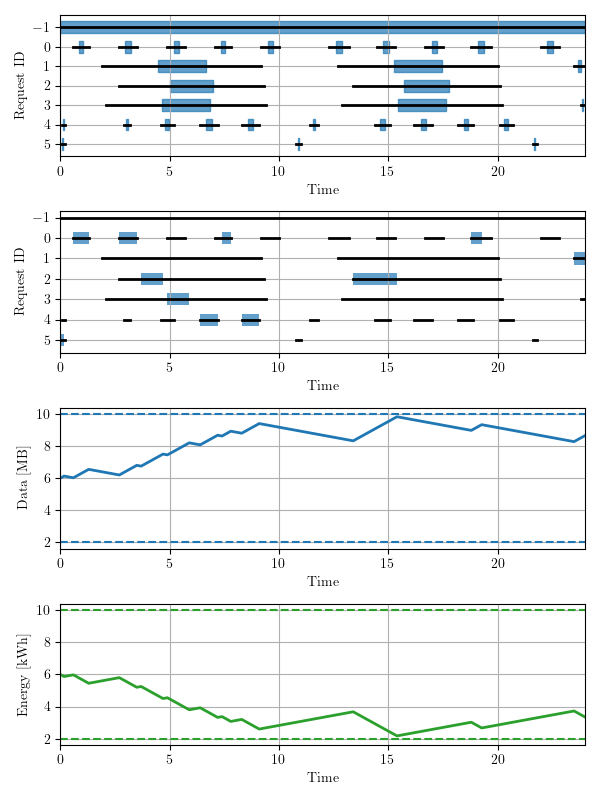

In [260]:
# MCTS
fig, axs = plt.subplots(4, 1, figsize=(6, 8))
plotting.plot_requests_service_windows(requests, service_windows, ax=axs[0])
plotting.plot_requests_service_windows(
    requests, service_windows, policy_mcts, ax=axs[1]
)
plotting.plot_resources(problem, policy_mcts, ax=axs[2:4])
plt.show()

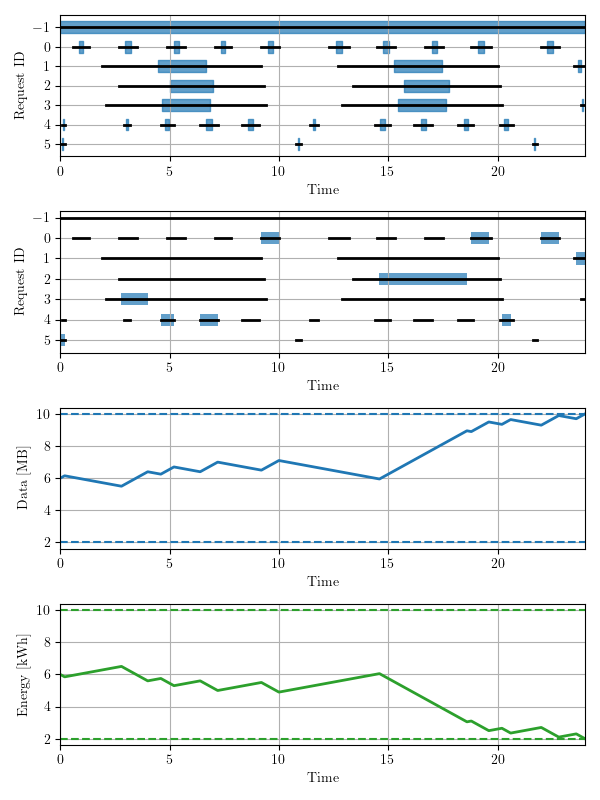

In [258]:
# IP
fig, axs = plt.subplots(4, 1, figsize=(6, 8))
plotting.plot_requests_service_windows(requests, service_windows, ax=axs[0])
plotting.plot_requests_service_windows(requests, service_windows, policy_ip, ax=axs[1])
plotting.plot_resources(problem, policy_ip, ax=axs[2:4])
plt.show()

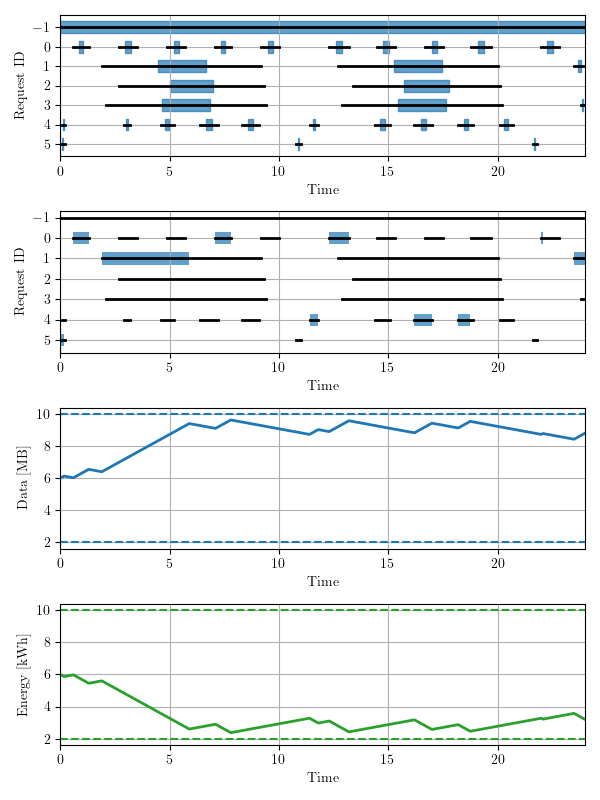

In [261]:
# Rule-based
fig, axs = plt.subplots(4, 1, figsize=(6, 8))
plotting.plot_requests_service_windows(requests, service_windows, ax=axs[0])
plotting.plot_requests_service_windows(requests, service_windows, policy_rb, ax=axs[1])
plotting.plot_resources(problem, policy_rb, ax=axs[2:4])
plt.show()